#### [SUPERCON Dataset](https://www.kaggle.com/datasets/chaozhuang/supercon-dataset/data)

In [2]:
import pandas as pd

def inspect_dataset(file_path):
    df = pd.read_csv(file_path)
    num_rows, num_cols = df.shape
    columns = df.columns.tolist()

    print("Number of rows:", num_rows)
    print("Number of columns:", num_cols)
    print("\nColumn names:")

    for col in columns:
        print(col)

    return df

df = inspect_dataset("archive\\featurized.csv")


Number of rows: 16521
Number of columns: 150

Column names:
formula
Tc
composition
category
0-norm
2-norm
3-norm
5-norm
7-norm
10-norm
MagpieData minimum Number
MagpieData maximum Number
MagpieData range Number
MagpieData mean Number
MagpieData avg_dev Number
MagpieData mode Number
MagpieData minimum MendeleevNumber
MagpieData maximum MendeleevNumber
MagpieData range MendeleevNumber
MagpieData mean MendeleevNumber
MagpieData avg_dev MendeleevNumber
MagpieData mode MendeleevNumber
MagpieData minimum AtomicWeight
MagpieData maximum AtomicWeight
MagpieData range AtomicWeight
MagpieData mean AtomicWeight
MagpieData avg_dev AtomicWeight
MagpieData mode AtomicWeight
MagpieData minimum MeltingT
MagpieData maximum MeltingT
MagpieData range MeltingT
MagpieData mean MeltingT
MagpieData avg_dev MeltingT
MagpieData mode MeltingT
MagpieData minimum Column
MagpieData maximum Column
MagpieData range Column
MagpieData mean Column
MagpieData avg_dev Column
MagpieData mode Column
MagpieData minimum Row


In [3]:
def explain_columns(columns):
    groups = {
    "Basic material info": [],
    "Norm features (composition complexity)": [],
    "Magpie elemental statistics": [],
    "Electronic structure features": [],
    "Ionic / bonding features": [],
    "Material composition fractions": [],
    "Other": []
    }

    for col in columns:
        if col in ["formula", "Tc", "composition", "category"]:
            groups["Basic material info"].append(col)

        elif "norm" in col:
            groups["Norm features (composition complexity)"].append(col)

        elif col.startswith("MagpieData"):
            groups["Magpie elemental statistics"].append(col)

        elif "valence electrons" in col:
            groups["Electronic structure features"].append(col)

        elif "ionic char" in col or "compound possible" in col:
            groups["Ionic / bonding features"].append(col)

        elif "transition metal fraction" in col:
            groups["Material composition fractions"].append(col)

        else:
            groups["Other"].append(col)

    explanations = {
        "Basic material info":
            "Thông tin cơ bản của vật liệu: công thức hóa học, nhiệt độ siêu dẫn (Tc), vector composition và category.",

        "Norm features (composition complexity)":
            "Các norm của vector thành phần nguyên tố. Chúng đo độ phức tạp hoặc độ phân bố của các nguyên tố trong hợp chất.",

        "Magpie elemental statistics":
            "Các đặc trưng được tính từ thuộc tính nguyên tử (atomic properties) trong bảng tuần hoàn. "
            "Đối với mỗi thuộc tính, dataset tính các statistic như minimum, maximum, range, mean, avg_dev, mode.",

        "Electronic structure features":
            "Số electron hóa trị trung bình trong các orbital s, p, d, f. Những đặc trưng này liên quan trực tiếp tới cấu trúc electron.",

        "Ionic / bonding features":
            "Đặc trưng mô tả khả năng tạo liên kết ion và tính chất hóa học của hợp chất.",

        "Material composition fractions":
            "Tỷ lệ của các loại nguyên tố đặc biệt (ví dụ transition metals) trong vật liệu.",

        "Other":
            "Các cột không thuộc nhóm trên."
    }

    for group, cols in groups.items():
        if len(cols) > 0:
            print(f"\n=== {group} ===")
            print(explanations[group])
            print("Columns:")
            for c in cols:
                print(" -", c)
                
explain_columns(df.columns)


=== Basic material info ===
Thông tin cơ bản của vật liệu: công thức hóa học, nhiệt độ siêu dẫn (Tc), vector composition và category.
Columns:
 - formula
 - Tc
 - composition
 - category

=== Norm features (composition complexity) ===
Các norm của vector thành phần nguyên tố. Chúng đo độ phức tạp hoặc độ phân bố của các nguyên tố trong hợp chất.
Columns:
 - 0-norm
 - 2-norm
 - 3-norm
 - 5-norm
 - 7-norm
 - 10-norm

=== Magpie elemental statistics ===
Các đặc trưng được tính từ thuộc tính nguyên tử (atomic properties) trong bảng tuần hoàn. Đối với mỗi thuộc tính, dataset tính các statistic như minimum, maximum, range, mean, avg_dev, mode.
Columns:
 - MagpieData minimum Number
 - MagpieData maximum Number
 - MagpieData range Number
 - MagpieData mean Number
 - MagpieData avg_dev Number
 - MagpieData mode Number
 - MagpieData minimum MendeleevNumber
 - MagpieData maximum MendeleevNumber
 - MagpieData range MendeleevNumber
 - MagpieData mean MendeleevNumber
 - MagpieData avg_dev Mendeleev

In [4]:
print(df.head())
print(df.info())

                formula     Tc             composition category  0-norm  \
0        Ag0.002Al0.998  1.128         Ag0.002 Al0.998    Other       2   
1        Ag0.005Zn0.995  0.763         Ag0.005 Zn0.995    Other       2   
2  Ag0.035Cd0.01Sn0.955  3.650  Ag0.035 Cd0.01 Sn0.955    Other       3   
3          Ag0.03Tl0.97  2.670           Ag0.03 Tl0.97    Other       2   
4    Ag0.05Rh0.04Ti0.91  1.950    Ag0.05 Rh0.04 Ti0.91    Other       3   

     2-norm    3-norm  5-norm  7-norm  10-norm  ...  \
0  0.998002  0.998000   0.998   0.998    0.998  ...   
1  0.995013  0.995000   0.995   0.995    0.995  ...   
2  0.955693  0.955016   0.955   0.955    0.955  ...   
3  0.970464  0.970010   0.970   0.970    0.970  ...   
4  0.912250  0.910076   0.910   0.910    0.910  ...   

   MagpieData avg_dev SpaceGroupNumber  MagpieData mode SpaceGroupNumber  \
0                              0.00000                             225.0   
1                              0.30845                            

In [5]:
def basic_overview(df):
    print("Dataset shape:", df.shape)

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum().sort_values(ascending=False))

    print("\nBasic statistics:")
    print(df.describe())

basic_overview(df)

Dataset shape: (16521, 150)

Data types:
formula                       object
Tc                           float64
composition                   object
category                      object
0-norm                         int64
                              ...   
avg f valence electrons      float64
compound possible               bool
max ionic char               float64
avg ionic char               float64
transition metal fraction    float64
Length: 150, dtype: object

Missing values:
formula                                 0
MagpieData minimum NpUnfilled           0
MagpieData range NpUnfilled             0
MagpieData mean NpUnfilled              0
MagpieData avg_dev NpUnfilled           0
                                       ..
MagpieData avg_dev CovalentRadius       0
MagpieData mode CovalentRadius          0
MagpieData minimum Electronegativity    0
MagpieData maximum Electronegativity    0
transition metal fraction               0
Length: 150, dtype: int64

Basic statistics:
 

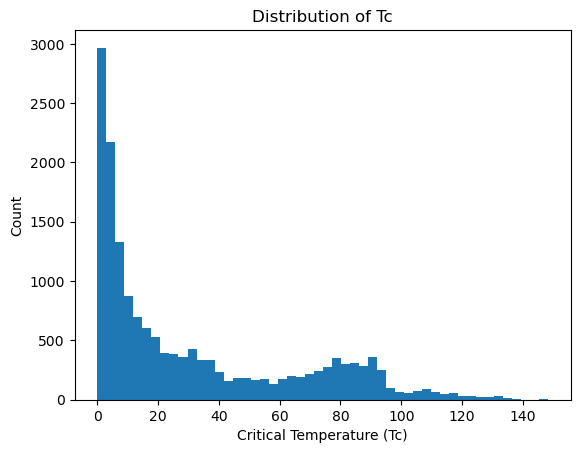

In [6]:
import matplotlib.pyplot as plt

def plot_target(df):
    plt.hist(df["Tc"], bins=50)
    plt.xlabel("Critical Temperature (Tc)")
    plt.ylabel("Count")
    plt.title("Distribution of Tc")
    plt.show()

plot_target(df)

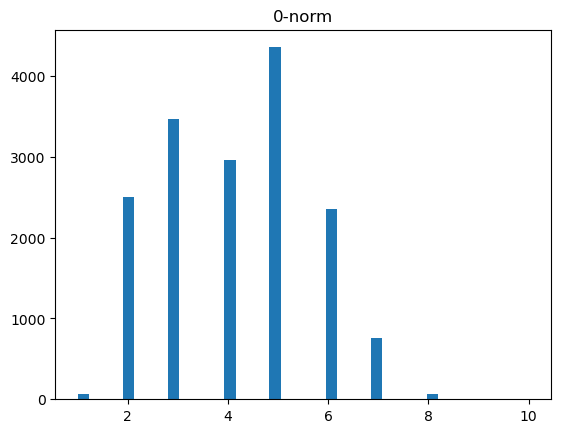

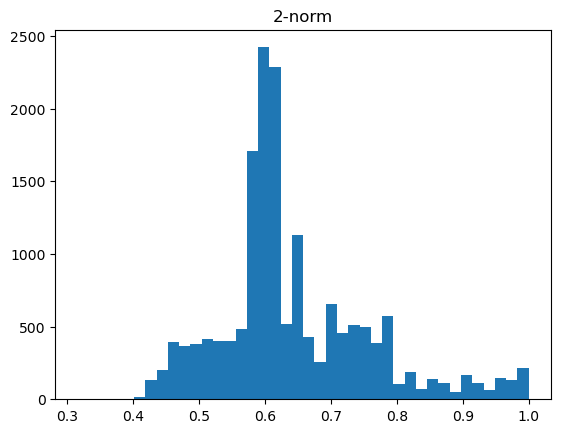

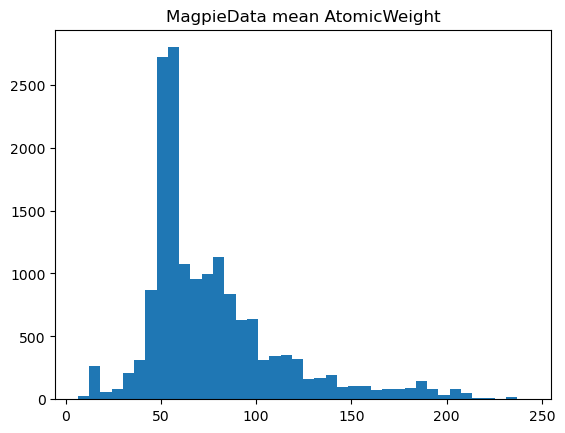

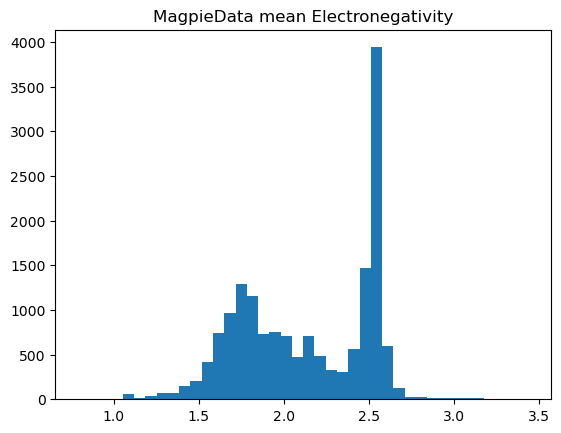

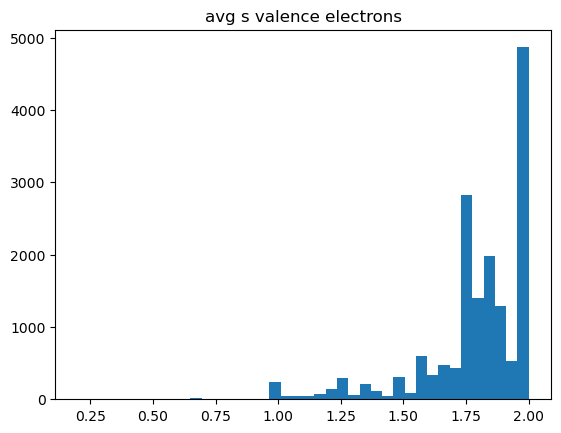

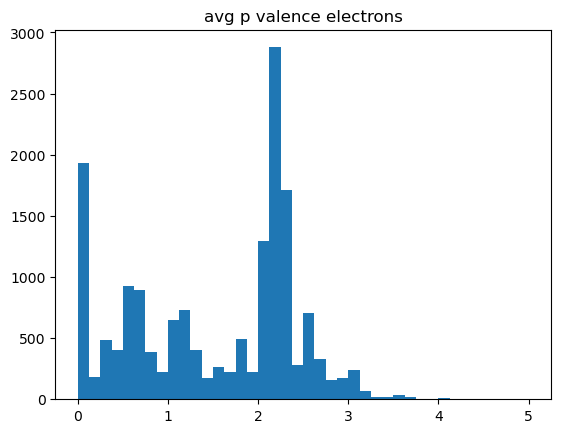

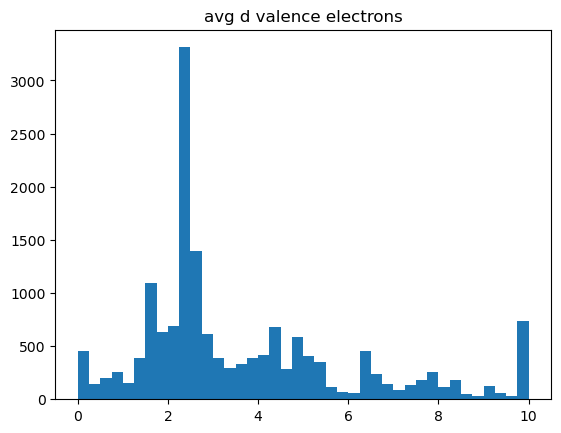

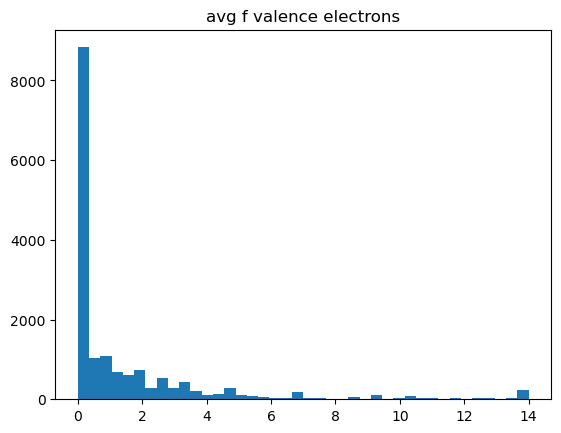

In [7]:
def plot_feature(df, feature):
    plt.hist(df[feature], bins=40)
    plt.title(feature)
    plt.show()

plot_feature(df, "0-norm")
plot_feature(df, "2-norm")
plot_feature(df, "MagpieData mean AtomicWeight")
plot_feature(df, "MagpieData mean Electronegativity")
plot_feature(df, "avg s valence electrons")
plot_feature(df, "avg p valence electrons")
plot_feature(df, "avg d valence electrons")
plot_feature(df, "avg f valence electrons")

In [8]:
def top_correlations(df, target="Tc"):
    corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)
    print(corr.head(50))
    
top_correlations(df)

Tc                                      1.000000
MagpieData avg_dev GSvolume_pa          0.674934
max ionic char                          0.666474
MagpieData range Electronegativity      0.658077
avg ionic char                          0.645520
MagpieData range GSvolume_pa            0.640880
0-norm                                  0.628522
MagpieData avg_dev Electronegativity    0.626278
MagpieData range CovalentRadius         0.619882
MagpieData maximum Electronegativity    0.619555
MagpieData maximum GSvolume_pa          0.614040
MagpieData avg_dev SpaceGroupNumber     0.588289
MagpieData range SpaceGroupNumber       0.582339
MagpieData avg_dev CovalentRadius       0.553096
MagpieData range MendeleevNumber        0.546263
MagpieData range Row                    0.543313
MagpieData avg_dev NdValence            0.540574
MagpieData range Column                 0.529751
MagpieData avg_dev MendeleevNumber      0.524458
MagpieData range NpValence              0.522163
MagpieData maximum N

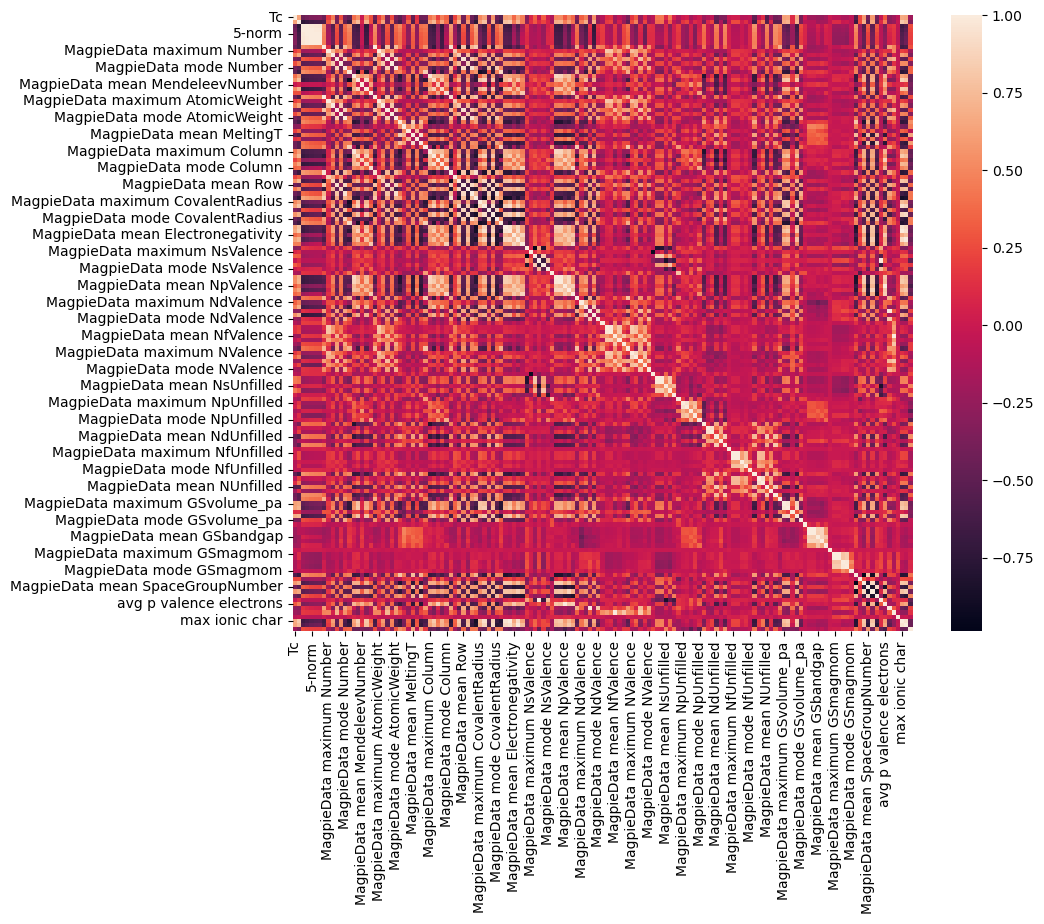

In [9]:
import seaborn as sns

def correlation_heatmap(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    sns.heatmap(corr)
    plt.show()
    
correlation_heatmap(df)

In [10]:
from sklearn.ensemble import RandomForestRegressor

def feature_importance(df):
    X = df.drop(columns=["Tc","formula","composition","category"])
    y = df["Tc"]


    model = RandomForestRegressor(n_estimators=100)
    model.fit(X, y)

    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(importance_df.head(20))


feature_importance(df)

                                  feature  importance
118        MagpieData avg_dev GSvolume_pa    0.541659
111             MagpieData mean NUnfilled    0.110990
44        MagpieData range CovalentRadius    0.025571
88          MagpieData avg_dev NsUnfilled    0.017074
32                MagpieData range Column    0.013812
145             transition metal fraction    0.013411
16     MagpieData avg_dev MendeleevNumber    0.010091
87             MagpieData mean NsUnfilled    0.009180
34              MagpieData avg_dev Column    0.008718
12     MagpieData minimum MendeleevNumber    0.008501
28            MagpieData avg_dev MeltingT    0.007708
21           MagpieData mean AtomicWeight    0.007661
1                                  2-norm    0.007576
50     MagpieData range Electronegativity    0.007273
46      MagpieData avg_dev CovalentRadius    0.007154
10              MagpieData avg_dev Number    0.006485
112          MagpieData avg_dev NUnfilled    0.006411
52   MagpieData avg_dev Elec

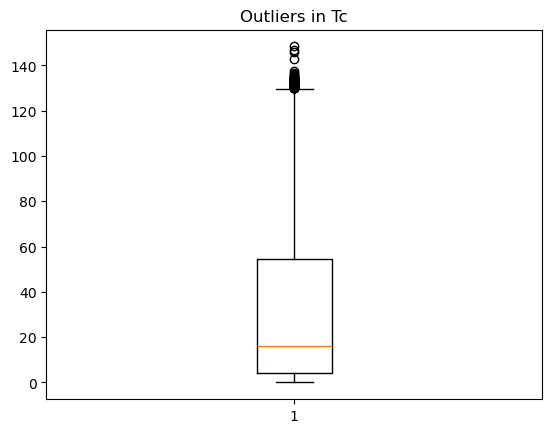

In [11]:
plt.boxplot(df["Tc"])
plt.title("Outliers in Tc")
plt.show()

# Exploratory Data Analysis (EDA) -- Superconductor Dataset

## 1. Tổng quan dataset

Dataset có:

-   **16521 samples**
-   **150 features**

### Các kiểu dữ liệu

-   **numeric**: phần lớn (\~145 cột)
-   **categorical/string**
    -   formula
    -   composition
    -   category
-   **boolean**
    -   compound possible

### Điểm quan trọng

Không có **missing values** trong bất kỳ cột nào.

Điều này khá hiếm trong dataset vật liệu và cho thấy:

-   dữ liệu đã được **tiền xử lý kỹ**
-   các feature **Magpie đã được tính toán hoàn chỉnh từ composition**

**Kết luận ban đầu**

Dataset **rất sạch**, có thể dùng trực tiếp cho ML mà **không cần xử lý
missing data**.

------------------------------------------------------------------------

## 2. Phân bố của biến mục tiêu Tc

Histogram của **Tc** cho thấy một đặc điểm rất rõ.

### Quan sát

-   phần lớn mẫu có **Tc \< 20 K**
-   một số cụm nhỏ ở **60--100 K**
-   có một số ít vật liệu **\> 120 K**

### Median và Mean

-   **mean Tc ≈ 31**
-   **median Tc ≈ 15.9**

Mean \> Median → **phân bố lệch phải (right skewed)**.

Điều này có nghĩa:

-   dataset có **nhiều vật liệu Tc thấp**
-   một số ít vật liệu **Tc rất cao**

Điều này phản ánh thực tế trong superconductors:

-   đa số vật liệu là **low‑Tc superconductors**
-   **high‑Tc materials (cuprates)** khá hiếm

### Boxplot

Boxplot xác nhận:

-   nhiều **outliers ở Tc cao (\~120--150 K)**

Các outliers này có thể là:

-   cuprates
-   iron‑based superconductors

### Kết luận

Dataset có **distribution imbalance**.

Điều này có thể ảnh hưởng đến:

-   regression model
-   loss function

### Một số hướng xử lý

-   log(Tc)
-   quantile transform
-   weighted regression

------------------------------------------------------------------------

## 3. Phân tích composition complexity (norm features)

Histogram của **0‑norm** cho thấy:

-   phổ biến nhất: **4--5 nguyên tố**
-   ít vật liệu có:
    -   **1 nguyên tố**
    -   **≥7 nguyên tố**

Mean:

-   **0‑norm ≈ 4.18**

Điều này hợp lý vì:

-   nhiều superconductors là **oxides phức tạp**

Ví dụ:

-   YBa₂Cu₃O₇\
-   Bi₂Sr₂CaCu₂O₈

Các vật liệu này có nhiều nguyên tố.

**Kết luận**

Superconductors thường là **multi‑element compounds**, không phải alloy
đơn giản.

------------------------------------------------------------------------

## 4. Phân bố của 2‑norm

2‑norm nằm chủ yếu trong khoảng:

**0.55 -- 0.65**

### Giải thích

2‑norm đo **độ tập trung của composition vector**.

-   gần **1** → dominated bởi 1 nguyên tố
-   nhỏ hơn → nhiều nguyên tố cân bằng

Vùng **0.6** nghĩa là:

composition tương đối **đa nguyên tố nhưng vẫn có nguyên tố chiếm ưu
thế**.

Điều này phù hợp với các vật liệu:

-   ABO₃
-   A₂BCO₄

------------------------------------------------------------------------

## 5. Phân tích AtomicWeight

Histogram của:

**MagpieData mean AtomicWeight**

cho thấy:

-   phần lớn nằm trong **40--100**
-   có **tail kéo dài tới \~200**

### Diễn giải

Dataset gồm:

-   nhiều nguyên tố **trung bình trong periodic table**
-   ít vật liệu chứa **very heavy elements**

Điều này cũng hợp lý vì superconductors phổ biến gồm:

-   Cu
-   Fe
-   Nb
-   Ba
-   Y
-   O

------------------------------------------------------------------------

## 6. Electronegativity

Histogram của:

**MagpieData mean Electronegativity**

cho thấy **bimodal distribution**.

Hai cluster:

-   **\~1.7--2.0**
-   **\~2.4--2.6**

### Diễn giải

Hai nhóm có thể tương ứng với:

**1. Metallic superconductors**

-   electronegativity thấp

**2. Oxide superconductors**

-   electronegativity cao do oxygen

Điều này gợi ý dataset có **nhiều family vật liệu khác nhau**.

------------------------------------------------------------------------

## 7. Valence electrons

### avg p valence electrons

phân bố chủ yếu:

**1.5 -- 2.5**

### avg d valence electrons

phân bố:

**2 -- 6**

Điều này rất quan trọng.

Nhiều superconductors chứa **transition metals**, ví dụ:

-   Cu
-   Fe
-   Ni
-   Nb

Các nguyên tố này có **d‑electrons**.

Histogram của **avg d valence electrons** xác nhận:

dataset chứa nhiều vật liệu **transition‑metal based**.

------------------------------------------------------------------------

## 8. avg f valence electrons

Histogram cho thấy:

-   phần lớn **= 0**

Điều này nghĩa là:

đa số vật liệu **không chứa lanthanides hoặc actinides**.

Chỉ một số ít vật liệu chứa:

**f‑electron elements**

Ví dụ:

-   rare‑earth superconductors

------------------------------------------------------------------------

## 9. Heatmap correlation

Heatmap cho thấy một điều rất quan trọng.

Rất nhiều **feature Magpie có correlation cao với nhau**.

### Nguyên nhân

Magpie features được tạo theo pattern:

-   minimum
-   maximum
-   range
-   mean
-   avg_dev
-   mode

cho cùng một thuộc tính.

Ví dụ:

-   AtomicWeight
-   Electronegativity
-   CovalentRadius

Những feature này **không độc lập**.

### Hệ quả

Dataset có **high multicollinearity**.

Điều này có thể gây vấn đề cho:

-   Linear Regression
-   Ridge
-   Lasso

Nhưng ít ảnh hưởng với:

-   Random Forest
-   Gradient Boosting
-   XGBoost

------------------------------------------------------------------------

## 10. Correlation với Tc

Top correlation features:

  Feature                          Correlation
  -------------------------------- -------------
  MagpieData avg_dev GSvolume_pa   0.67
  max ionic char                   0.66
  range Electronegativity          0.66
  avg ionic char                   0.65
  0-norm                           0.63

### Ý nghĩa vật lý

#### Electronegativity range

Superconductors thường có:

-   nguyên tố **kim loại**
-   nguyên tố **phi kim (O, As)**

→ electronegativity difference lớn.

#### Ionic character

`max ionic char` và `avg ionic char` cao.

Điều này phù hợp với **oxide superconductors**.

Ví dụ:

YBa₂Cu₃O₇

#### 0‑norm

Số nguyên tố trong compound.

Correlation \~0.63 cho thấy:

**compound phức tạp hơn → Tc có xu hướng cao hơn**.

Điều này phản ánh:

**high‑Tc superconductors thường là complex oxides**.

------------------------------------------------------------------------

## 11. Feature importance (RandomForest)

Feature quan trọng nhất:

**MagpieData avg_dev GSvolume_pa**

importance ≈ **0.54**

Feature này đo:

**variation của ground state volume per atom**.

### Liên quan đến

-   lattice structure
-   electron mobility
-   phonon interactions

Điều này phù hợp với **lý thuyết BCS**:

electron--phonon coupling phụ thuộc vào **lattice properties**.

### Các feature quan trọng khác

-   mean NUnfilled
-   range CovalentRadius
-   range Electronegativity
-   transition metal fraction

Tất cả đều có **ý nghĩa vật lý rõ ràng**.

------------------------------------------------------------------------

## 12. Một số kết luận quan trọng

### 1

Dataset chứa **nhiều loại superconductors khác nhau**.

Có thể gồm:

-   conventional superconductors
-   cuprates
-   iron‑based

### 2

High‑Tc materials có xu hướng:

-   composition phức tạp
-   electronegativity difference cao
-   ionic character cao

### 3

Feature quan trọng nhất liên quan tới:

-   atomic volume
-   lattice structure

Điều này phản ánh **physics của superconductivity**.

### 4

Dataset có **multicollinearity mạnh**.

Nhiều feature Magpie gần như **redundant**.

------------------------------------------------------------------------

## 13. Một số câu hỏi nghiên cứu tiếp theo

### Question 1

High Tc materials có thuộc **category nào**?

Nên vẽ:

-   Tc vs category

### Question 2

Tc có phụ thuộc mạnh vào **transition metal fraction** không?

### Question 3

Electronegativity range cao có thực sự tạo ra **Tc cao hơn**?

Plot:

-   scatter(Tc, electronegativity_range)

### Question 4

Có tồn tại **cluster vật liệu** không?

Có thể thử:

-   PCA
-   UMAP
-   t‑SNE

để xem dataset có phân thành nhóm.

### Question 5

Feature quan trọng nhất (**GSvolume_pa**) có tương quan **tuyến tính**
với Tc không?

Hay chỉ RandomForest khai thác **nonlinear relation**?

------------------------------------------------------------------------

## 14. Bước EDA tiếp theo khuyến nghị

Nếu tiếp tục phân tích dataset này, nên làm thêm:

1.  **PCA visualization**\
    → xem cluster vật liệu

2.  **Feature selection**\
    → giảm từ **150 xuống \~20 feature**

3.  **Scatter plot Tc vs top features**

4.  **Pairplot top 5 features**

5.  **log(Tc) distribution**